In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

print("All libraries are ready")

All libraries are ready


In [2]:
houses = pd.DataFrame({
    "area": [100, 120, 150, 180, 200],
    "bedrooms": [2, 2, 3, 3, 4],
    "age": [10, 8, 6, 4, 2],
    "price": [50000, 60000, 80000, 95000, 120000]
})

houses

,area,bedrooms,age,price
0,100,2,10,50000
1,120,2,8,60000
2,150,3,6,80000
3,180,3,4,95000
4,200,4,2,120000


In [3]:
from sklearn.linear_model import LinearRegression

X = houses[["area", "bedrooms", "age"]]
y = houses["price"]

model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0. ,11666.67,-5833.33]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['area','bedrooms','age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.333e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [5]:
new_house = pd.DataFrame({
    "area": [220],
    "bedrooms": [4],
    "age": [1]
})

prediction = model.predict(new_house)

print(prediction)

[124166.66666667]


In [6]:
print(model.coef_)

[ 8.90579335e-13  1.16666667e+04 -5.83333333e+03]


In [7]:
print(model.intercept_)

83333.3333333331


المعادلة التي تعلمها النموذج

أصبحت تقريباً:

price =
83333.33
+
(11666.67 × bedrooms)
-
(5833.33 × age)

In [8]:
houses

,area,bedrooms,age,price
0,100,2,10,50000
1,120,2,8,60000
2,150,3,6,80000
3,180,3,4,95000
4,200,4,2,120000


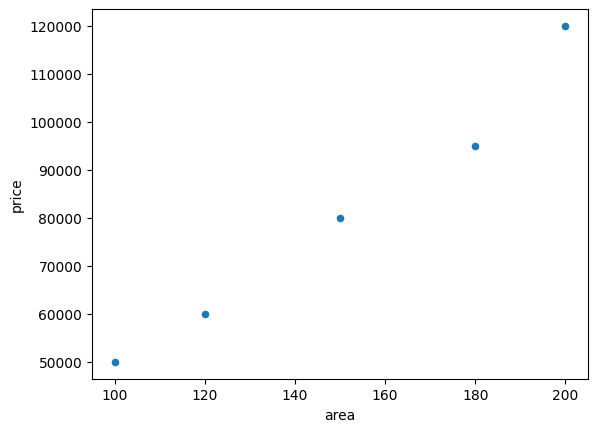

In [9]:
import matplotlib.pyplot as plt

houses.plot(
    x="area",
    y="price",
    kind="scatter"
)

plt.show()

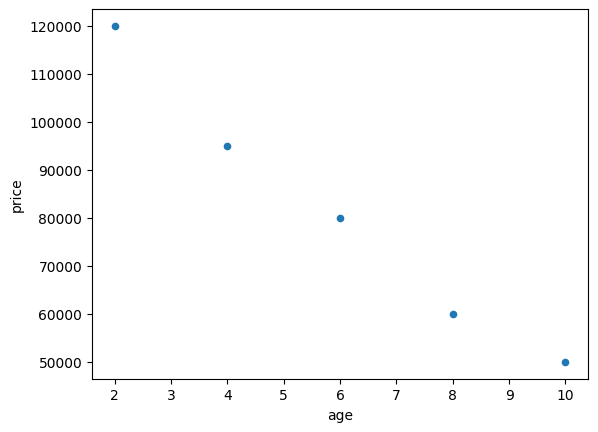

In [10]:
houses.plot(
    x="age",
    y="price",
    kind="scatter"
)

plt.show()

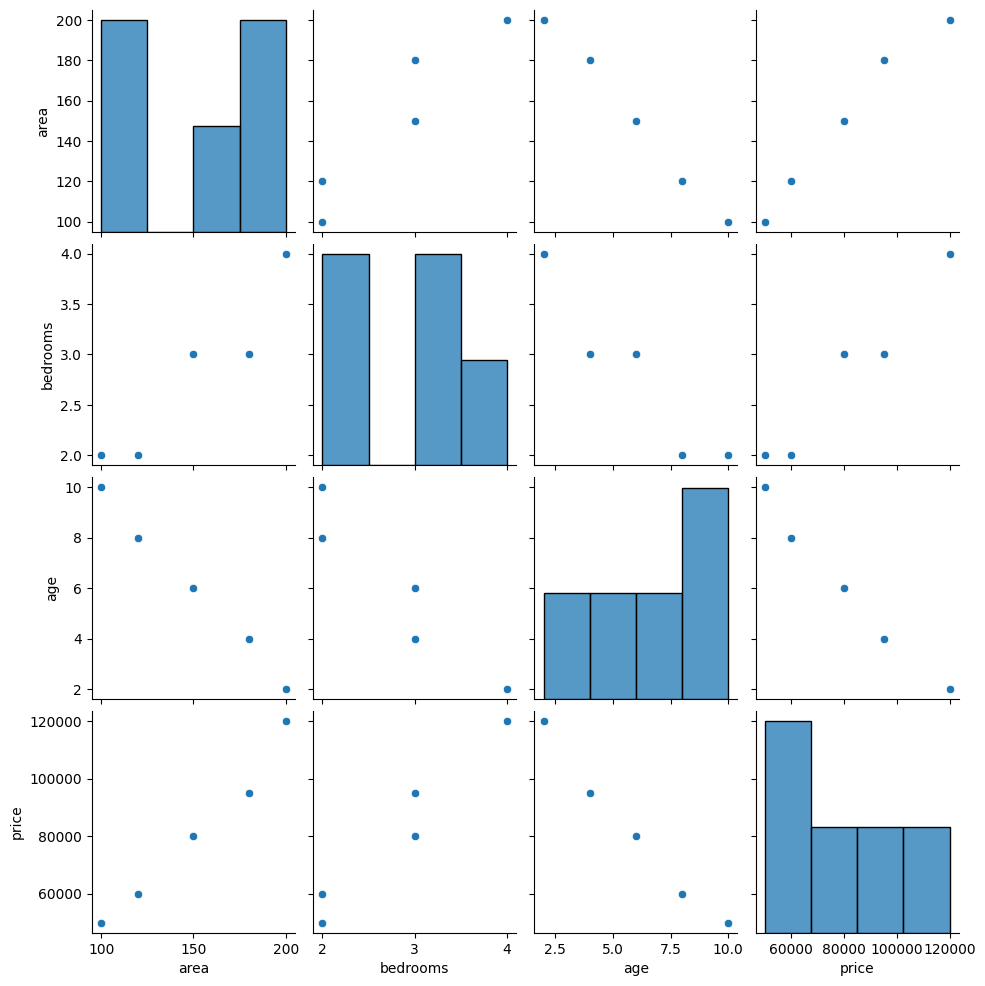

In [11]:
import seaborn as sns

sns.pairplot(houses)

plt.show()

In [12]:
houses.corr(numeric_only=True)

,area,bedrooms,age,price
area,1.000000,0.942128,-0.997054,0.987824
bedrooms,0.942128,1.000000,-0.944911,0.973610
age,-0.997054,-0.944911,1.000000,-0.990742
price,0.987824,0.973610,-0.990742,1.000000


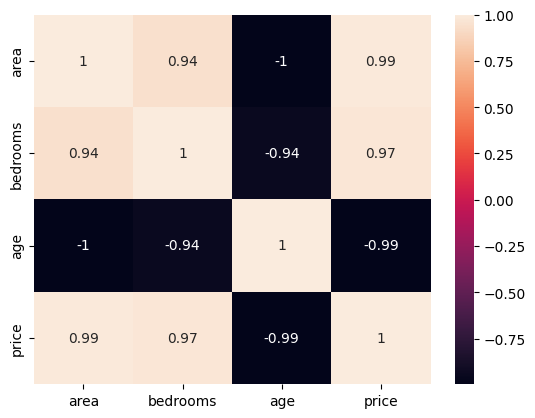

In [13]:
sns.heatmap(
    houses.corr(numeric_only=True),
    annot=True
)

plt.show()

In [14]:
houses.corr(numeric_only=True)

,area,bedrooms,age,price
area,1.000000,0.942128,-0.997054,0.987824
bedrooms,0.942128,1.000000,-0.944911,0.973610
age,-0.997054,-0.944911,1.000000,-0.990742
price,0.987824,0.973610,-0.990742,1.000000


In [15]:
from sklearn.model_selection import train_test_split

X = houses[["area", "bedrooms", "age"]]
y = houses["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 4
Testing rows: 1


In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

score = model.score(X_test, y_test)

print(score)

nan


c:\Users\takam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [18]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ -89.47,10771.98,-7175.36]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['area','bedrooms','age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.075e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
